In [5]:
# TIP: Use DataWrangler to view the DataFrame
query = 'RDF AND BIM AND reasoning'

In [6]:
import requests
import pandas as pd
import json

# Retrieve all results using pagination (OpenAlex: max 200 per page)
all_records = []
page = 1
while True:
    paged_url = f'https://api.openalex.org/works?search={query}&per_page=200&page={page}'
    resp = requests.get(paged_url).json()
    records = resp.get('results', [])
    if not records:
        break
    all_records.extend(records)
    page += 1
    # Optional: stop after a certain number of pages to avoid long runtime
    if page > 5: break  # Remove or adjust as needed
# Save all records to a single JSON file
with open('results.json', 'w') as f:
    json.dump(all_records, f, indent=2)

dataframe = pd.DataFrame([{
    'cited_by_count': r['cited_by_count'],
    'year': r['publication_year'],
    'title': r['title'],
    'doi': r['doi'],
    'authors': [auth['author']['display_name'] for auth in r['authorships']],
    'relevance_score': r['relevance_score'],
    'abstract': r.get('abstract_inverted_index'),
} for r in all_records])
print(f'Total records retrieved: {len(dataframe)}')

Total records retrieved: 308


In [7]:
# Sort the DataFrame by most cited (descending by cited_by_count)
if 'cited_by_count' in dataframe.columns:
    dataframe = dataframe.sort_values(by='cited_by_count', ascending=False)
    print(dataframe[['title', 'cited_by_count', "doi"]].head(10))

                                                title  cited_by_count  \
3   Towards a semantic Construction Digital Twin: ...            1010   
9   Review of built heritage modelling: Integratio...             235   
6   BOT: The building topology ontology of the W3C...             222   
8                                               Brick             217   
22  Tendencies of Technologies and Platforms in Sm...             216   
7   Linking building data in the cloud: Integratin...             207   
11  Geospatial Data Management Research: Progress ...             161   
23  Big Data for Energy Management and Energy-Effi...             146   
10  Enhancing the ifcOWL ontology with an alternat...             109   
14       The promise of automated compliance checking             104   

                                             doi  
3   https://doi.org/10.1016/j.autcon.2020.103179  
9   https://doi.org/10.1016/j.culher.2020.05.008  
6              https://doi.org/10.3233/sw-2

In [8]:
# Count the number of papers per author and rank them
from collections import Counter

author_list = [author for authors in dataframe['authors'] for author in authors]
author_counts = Counter(author_list)
ranked_authors = author_counts.most_common()

# Display the top 10 authors with the most papers
for i, (author, count) in enumerate(ranked_authors[:20], 1):
    print(f"{i}. {author}: {count} papers")

1. Pieter Pauwels: 24 papers
2. Jakob Beetz: 7 papers
3. James O’Donnell: 6 papers
4. Yacine Rezgui: 4 papers
5. Edward Corry: 4 papers
6. Bauke de Vries: 4 papers
7. Roland Billen: 4 papers
8. Francesca Noardo: 4 papers
9. Mathias Bonduel: 4 papers
10. Haijiang Li: 4 papers
11. Peter Johansson: 4 papers
12. Seppo Törmä: 4 papers
13. Judith Michael: 4 papers
14. István Koren: 4 papers
15. Iraklis Dimitriadis: 4 papers
16. Judith Fulterer: 4 papers
17. Aymen Gannouni: 4 papers
18. Malte Heithoff: 4 papers
19. Annkristin Hermann: 4 papers
20. Katharina Hornberg: 4 papers


## Publication Timeline Analysis
Analyze how research in this area has evolved over time

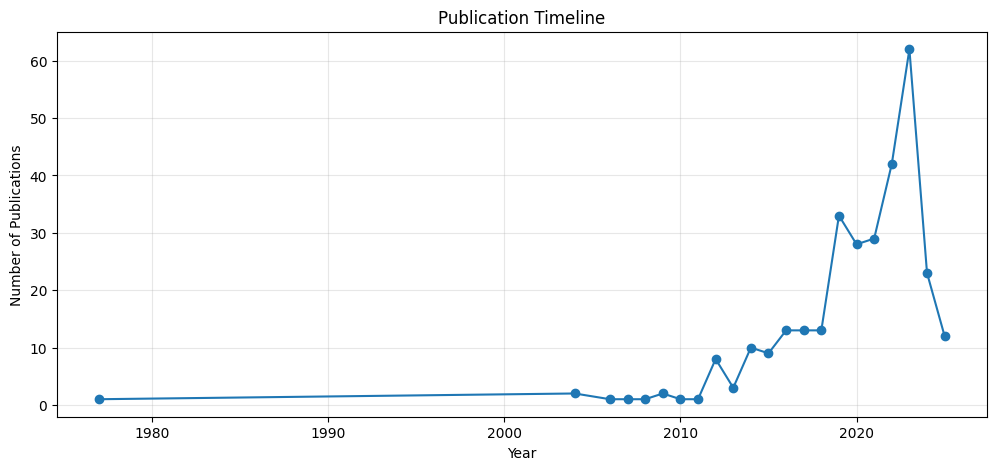


Total publications by period:
Before 2015: 31
2015-2019: 81
2020-present: 196


In [10]:
# Publications per year
import matplotlib.pyplot as plt

if 'year' in dataframe.columns:
    year_counts = dataframe['year'].value_counts().sort_index()
    
    plt.figure(figsize=(12, 5))
    plt.plot(year_counts.index, year_counts.values, marker='o')
    plt.xlabel('Year')
    plt.ylabel('Number of Publications')
    plt.title('Publication Timeline')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"\nTotal publications by period:")
    print(f"Before 2015: {len(dataframe[dataframe['year'] < 2015])}")
    print(f"2015-2019: {len(dataframe[(dataframe['year'] >= 2015) & (dataframe['year'] < 2020)])}")
    print(f"2020-present: {len(dataframe[dataframe['year'] >= 2020])}")

## Identify Seminal Papers
Find foundational papers (older + highly cited) vs emerging work (recent + growing citations)

In [ ]:
# Identify seminal papers (older, highly cited foundational work)
current_year = 2026
dataframe['age'] = current_year - dataframe['year']

# Seminal papers: older than 3 years and highly cited
seminal = dataframe[dataframe['age'] > 3].nlargest(10, 'cited_by_count')
print("=== Top 10 Seminal Papers (Foundational Work) ===")
for idx, row in seminal.iterrows():
    print(f"\n{row['title']}")
    print(f"  Year: {row['year']} | Citations: {row['cited_by_count']} | DOI: {row['doi']}")

=== Top 10 Seminal Papers (Foundational Work) ===

Towards a semantic Construction Digital Twin: Directions for future research
  Year: 2020 | Citations: 1010 | DOI: https://doi.org/10.1016/j.autcon.2020.103179

Review of built heritage modelling: Integration of HBIM and other information techniques
  Year: 2020 | Citations: 235 | DOI: https://doi.org/10.1016/j.culher.2020.05.008

BOT: The building topology ontology of the W3C linked building data group
  Year: 2020 | Citations: 222 | DOI: https://doi.org/10.3233/sw-200385

Brick
  Year: 2016 | Citations: 217 | DOI: https://doi.org/10.1145/2993422.2993577

Tendencies of Technologies and Platforms in Smart Cities: A State‐of‐the‐Art Review
  Year: 2018 | Citations: 216 | DOI: https://doi.org/10.1155/2018/3086854

Linking building data in the cloud: Integrating cross-domain building data using linked data
  Year: 2012 | Citations: 207 | DOI: https://doi.org/10.1016/j.aei.2012.10.003

Geospatial Data Management Research: Progress and Futu

In [16]:
# Emerging papers: recent (last 3 years) with decent citations
print("\n\n=== Emerging Important Papers (Last 3 Years) ===")
emerging = dataframe[dataframe['age'] <= 3].nlargest(10, 'cited_by_count')
for idx, row in emerging.iterrows():
    print(f"\n{row['title']}")
    print(f"  Year: {row['year']} | Citations: {row['cited_by_count']} | DOI: {row['doi']}")



=== Emerging Important Papers (Last 3 Years) ===

Recent Technological Advancements in BIM and LCA Integration for Sustainable Construction: A Review
  Year: 2024 | Citations: 87 | DOI: https://doi.org/10.3390/su16031340

Architectural Reply for Smart Building Design Concepts Based on Artificial Intelligence Simulation Models and Digital Twins
  Year: 2023 | Citations: 60 | DOI: https://doi.org/10.3390/su15064955

Faceting the post-disaster built heritage reconstruction process within the digital twin framework for Notre-Dame de Paris
  Year: 2023 | Citations: 50 | DOI: https://doi.org/10.1038/s41598-023-32504-9

BIM–GIS Integrated Utilization in Urban Disaster Management: The Contributions, Challenges, and Future Directions
  Year: 2023 | Citations: 48 | DOI: https://doi.org/10.3390/rs15051331

An End-to-End Implementation of a Service-Oriented Architecture for Data-Driven Smart Buildings
  Year: 2023 | Citations: 39 | DOI: https://doi.org/10.1109/access.2023.3325767

Automated Buil

## Citation Distribution Analysis
Understand the citation landscape and identify highly influential papers

=== Citation Statistics ===
Total papers: 308
Mean citations: 21.2
Median citations: 7.0
Max citations: 1010
Papers with 0 citations: 44
Papers with >100 citations: 11
Papers with >50 citations: 26


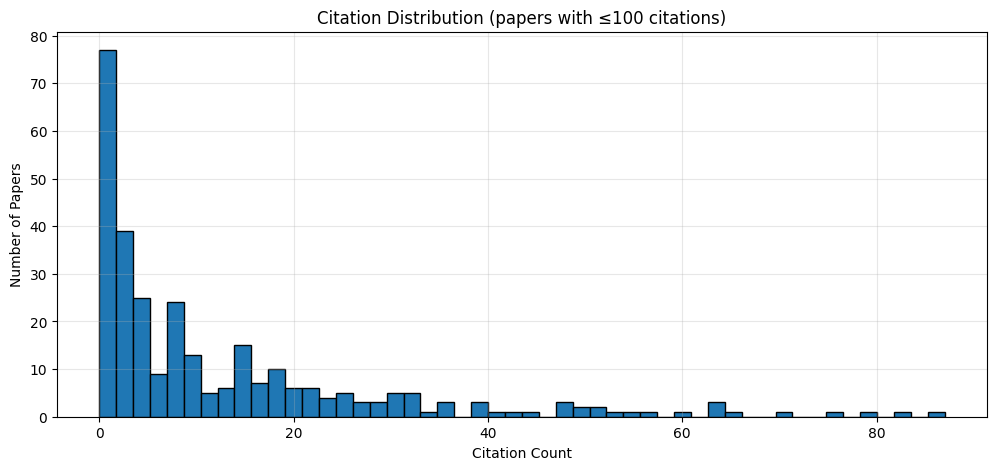

In [12]:
# Citation statistics and distribution
import numpy as np

citations = dataframe['cited_by_count']
print("=== Citation Statistics ===")
print(f"Total papers: {len(dataframe)}")
print(f"Mean citations: {citations.mean():.1f}")
print(f"Median citations: {citations.median():.1f}")
print(f"Max citations: {citations.max()}")
print(f"Papers with 0 citations: {len(dataframe[dataframe['cited_by_count'] == 0])}")
print(f"Papers with >100 citations: {len(dataframe[dataframe['cited_by_count'] > 100])}")
print(f"Papers with >50 citations: {len(dataframe[dataframe['cited_by_count'] > 50])}")

# Citation histogram
plt.figure(figsize=(12, 5))
plt.hist(citations[citations <= 100], bins=50, edgecolor='black')
plt.xlabel('Citation Count')
plt.ylabel('Number of Papers')
plt.title('Citation Distribution (papers with ≤100 citations)')
plt.grid(True, alpha=0.3)
plt.show()

## Research Velocity Analysis
Identify papers with high citation rates (citations per year)

In [13]:
# Calculate citation velocity (citations per year since publication)
dataframe['citations_per_year'] = dataframe['cited_by_count'] / dataframe['age'].replace(0, 1)

# Top papers by citation velocity (impact rate)
print("=== Top 15 Papers by Citation Velocity (citations/year) ===")
velocity_top = dataframe.nlargest(15, 'citations_per_year')
for idx, row in velocity_top.iterrows():
    print(f"\n{row['title']}")
    print(f"  Year: {row['year']} | Total Citations: {row['cited_by_count']} | Citations/Year: {row['citations_per_year']:.1f}")
    print(f"  DOI: {row['doi']}")

=== Top 15 Papers by Citation Velocity (citations/year) ===

Towards a semantic Construction Digital Twin: Directions for future research
  Year: 2020 | Total Citations: 1010 | Citations/Year: 168.3
  DOI: https://doi.org/10.1016/j.autcon.2020.103179

Recent Technological Advancements in BIM and LCA Integration for Sustainable Construction: A Review
  Year: 2024 | Total Citations: 87 | Citations/Year: 43.5
  DOI: https://doi.org/10.3390/su16031340

Review of built heritage modelling: Integration of HBIM and other information techniques
  Year: 2020 | Total Citations: 235 | Citations/Year: 39.2
  DOI: https://doi.org/10.1016/j.culher.2020.05.008

BOT: The building topology ontology of the W3C linked building data group
  Year: 2020 | Total Citations: 222 | Citations/Year: 37.0
  DOI: https://doi.org/10.3233/sw-200385

Tendencies of Technologies and Platforms in Smart Cities: A State‐of‐the‐Art Review
  Year: 2018 | Total Citations: 216 | Citations/Year: 27.0
  DOI: https://doi.org/10.11

## Co-authorship Analysis
Identify research collaborations and key author networks

In [14]:
# Find frequent co-author pairs
from itertools import combinations
from collections import Counter

coauthor_pairs = []
for authors in dataframe['authors']:
    if len(authors) > 1:
        # Get all pairs of co-authors for this paper
        pairs = list(combinations(sorted(authors), 2))
        coauthor_pairs.extend(pairs)

coauthor_counts = Counter(coauthor_pairs)
print("=== Top 15 Co-author Pairs ===")
for i, ((author1, author2), count) in enumerate(coauthor_counts.most_common(15), 1):
    print(f"{i}. {author1} & {author2}: {count} papers together")

=== Top 15 Co-author Pairs ===
1. Annkristin Hermann & Aymen Gannouni: 4 papers together
2. Annkristin Hermann & Bernhard Rumpe⋆: 4 papers together
3. Annkristin Hermann & Christian Hopmann: 4 papers together
4. Annkristin Hermann & Günther Schuh: 4 papers together
5. Annkristin Hermann & Iraklis Dimitriadis: 4 papers together
6. Annkristin Hermann & István Koren: 4 papers together
7. Annkristin Hermann & Johannes Lipp: 4 papers together
8. Annkristin Hermann & Judith Fulterer: 4 papers together
9. Annkristin Hermann & Judith Michael: 4 papers together
10. Annkristin Hermann & Katharina Hornberg: 4 papers together
11. Annkristin Hermann & Malte Heithoff: 4 papers together
12. Annkristin Hermann & Matthias Jarke: 4 papers together
13. Annkristin Hermann & Moritz Kröger: 4 papers together
14. Annkristin Hermann & Niklas Schäfer: 4 papers together
15. Annkristin Hermann & Patrick Sapel: 4 papers together


## Research Gaps & Opportunities
Find recent papers that might need more attention

In [15]:
# Recent papers with high relevance but low citations (potential research opportunities)
recent_papers = dataframe[dataframe['year'] >= 2023]
if len(recent_papers) > 0:
    underrated = recent_papers.nsmallest(10, 'cited_by_count').nlargest(10, 'relevance_score')
    print("=== Recent High-Relevance Papers with Low Citations (Research Opportunities) ===")
    for idx, row in underrated.iterrows():
        print(f"\n{row['title']}")
        print(f"  Year: {row['year']} | Citations: {row['cited_by_count']} | Relevance: {row['relevance_score']:.2f}")
        print(f"  DOI: {row['doi']}")
else:
    print("No papers from 2023 or later found in dataset.")

=== Recent High-Relevance Papers with Low Citations (Research Opportunities) ===

Vision-based Information Management using Digital Construction Knowledge Graphs to Integrate Data in Digital Twins for Prefabricated Construction
  Year: 2025 | Citations: 0 | Relevance: 6.36
  DOI: https://doi.org/10.26190/unsworks/31753

Visualizing ESG Performance in an Integrated GIS–BIM–IoT Platform for Strategic Urban Planning
  Year: 2025 | Citations: 0 | Relevance: 5.03
  DOI: https://doi.org/10.3390/buildings15183394

The Formal Graph of APRDF
  Year: 2023 | Citations: 0 | Relevance: 0.72
  DOI: https://doi.org/10.18517/ijaseit.13.5.18438

Development of a Built Environment Ontology Lookup Service (BE-OLS) with a New Ontology Evaluation
  Year: 2025 | Citations: 0 | Relevance: 0.61
  DOI: https://doi.org/10.35490/ec3.2025.353

A Semantic Retrieval Algorithm for Enterprise Archives Based on Bert-BiGRU-CRF-Harris Hawk Model
  Year: 2024 | Citations: 0 | Relevance: 0.58
  DOI: https://doi.org/10.212